# Brent Crude — Geopolitical Event Impact Analysis
**Middle East Crisis 2023–2026** | EDA & Event Study

This notebook analyzes the impact of Middle East geopolitical events on Brent crude oil prices.
It covers price dynamics, return distributions, event impact studies, and macro correlations.

**Data sources:** Yahoo Finance (Brent, DXY, VIX, TTF, Gold, SPX) | Manually curated event timeline

**Period:** January 2020 → March 2026

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import scipy.stats as stats

#ROOT    = Path().resolve().parent
#RAW     = ROOT / 'raw'
#PROC    = ROOT / 'processed'
RAW  = Path(r'C:\Users\Thibaut\AppData\Local\Programs\Microsoft VS Code\data\raw')
PROC = Path(r'C:\Users\Thibaut\AppData\Local\Programs\Microsoft VS Code\data\processed')

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 30)

## 1. Load Data

In [2]:
brent = pd.read_csv(RAW / 'brent_prices.csv', index_col='date', parse_dates=True)
brent = brent[['open','high','low','close','volume']].dropna(subset=['close'])

events = pd.read_csv(RAW / 'geopolitical_events.csv', parse_dates=['date']).set_index('date').sort_index()

macro_files = {'dxy': 'macro_dxy.csv', 'vix': 'macro_vix.csv',
               'ttf': 'macro_ttf.csv', 'gold': 'macro_gold.csv', 'spx': 'macro_spx.csv'}
macro = pd.concat([
    pd.read_csv(RAW / f, index_col='date', parse_dates=True).rename(columns=lambda c: name)
    for name, f in macro_files.items()
], axis=1)
macro.index = pd.to_datetime(macro.index)

df = brent.join(macro, how='left').ffill()
df['ret']     = df['close'].pct_change()
df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
df['vol_30d'] = df['ret'].rolling(30).std() * np.sqrt(252)
df['vol_7d']  = df['ret'].rolling(7).std()  * np.sqrt(252)

print(f'{len(df)} trading days  |  {df.index[0].date()} -> {df.index[-1].date()}')
print(f'Current price : ${df.close.iloc[-1]:.2f}/bbl')
df.tail(3)

1559 trading days  |  2020-01-02 -> 2026-03-12
Current price : $100.46/bbl


,open,high,low,close,volume,dxy,vix,ttf,gold,spx,ret,log_ret,vol_30d,vol_7d
date,,,,,,,,,,,,,,
2026-03-10,92.45,95.08,81.16,87.80,144614,98.83,24.93,47.39,5229.70,6781.48,-0.11,-0.12,0.61,1.09
2026-03-11,91.30,93.25,86.32,91.98,101940,99.23,24.23,49.99,5167.40,6775.80,0.05,0.05,0.62,1.06
2026-03-12,93.74,101.80,93.70,100.46,101940,99.74,27.29,50.87,5115.80,6672.62,0.09,0.09,0.66,1.13


## 2. Price Series & Realized Volatility

The chart below shows Brent crude prices from 2020 to 2026, with major geopolitical events annotated.
- 🔴 **Red markers** = events with high Strait of Hormuz closure risk
- 🟠 **Orange markers** = other major geopolitical events (severity ≥ 4/5)
- **Dashed line** = 30-day moving average

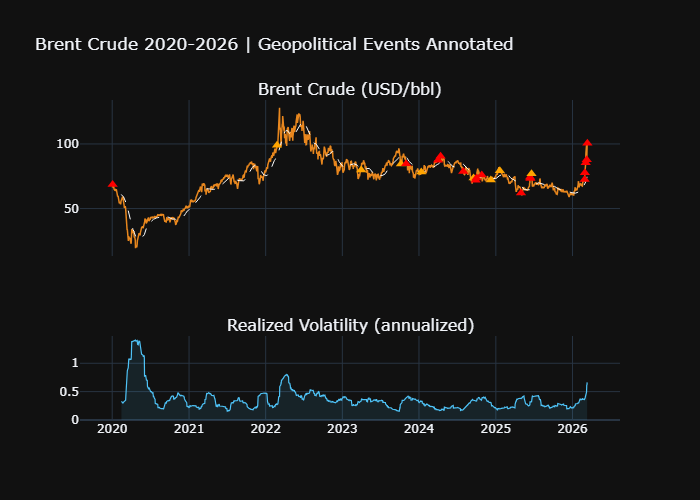

In [3]:
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    row_heights=[0.65, 0.35],
                    subplot_titles=['Brent Crude (USD/bbl)', 'Realized Volatility (annualized)'])

fig.add_trace(go.Scatter(x=df.index, y=df.close, name='Brent',
                         line=dict(color='#E8871E', width=1.5)), row=1, col=1)
fig.add_trace(go.Scatter(x=df.index, y=df.close.rolling(30).mean(), name='MA30',
                         line=dict(color='white', width=1, dash='dash')), row=1, col=1)

major = events[events.severity >= 4]
for dt, row in major.iterrows():
    idx = df.index.get_indexer([dt], method='nearest')[0]
    price = df.close.iloc[idx]
    color = 'red' if str(row.get('strait_hormuz_risk','')).lower() in ['high','very_high','critical'] else 'orange'
    fig.add_trace(go.Scatter(
        x=[dt], y=[price], mode='markers',
        marker=dict(size=9, color=color, symbol='triangle-up'),
        showlegend=False,
        hovertext=f"{row['event']}<br>Severity {row['severity']}/5"
    ), row=1, col=1)

fig.add_trace(go.Scatter(x=df.index, y=df.vol_30d, name='Vol 30d',
                         line=dict(color='#4FC3F7', width=1.2),
                         fill='tozeroy', fillcolor='rgba(79,195,247,0.1)'), row=2, col=1)

fig.update_layout(template='plotly_dark', height=600,
                  title='Brent Crude 2020-2026 | Geopolitical Events Annotated',
                  hovermode='x unified', showlegend=False)
fig.show(renderer='png')

## 3. Return Distribution

**Key results:**
- **Kurtosis = 14.1** — extremely fat tails (normal distribution = 0). Extreme moves happen far more often than standard models assume
- **Skewness = -0.70** — slight negative skew, meaning crashes tend to be more violent than spikes
- **Largest single-day drop: -24.4%** on April 21, 2020 — COVID demand collapse, WTI briefly went negative
- **Largest single-day spike: +21.0%** on April 2, 2020 — Trump-brokered Saudi-Russia production cut deal
- **Practical implication:** any model assuming normally distributed returns will significantly underestimate tail risk

In [4]:
rets = df.ret.dropna()

print('=== Daily returns descriptive stats ===')
print(rets.describe().to_string())
print(f'\nSkewness : {rets.skew():.3f}')
print(f'Kurtosis : {rets.kurtosis():.3f}  (normal = 0, fat tails > 0)')
print(f'\nTop 5 single-day drops:')
print(rets.nsmallest(5).to_string())
print(f'\nTop 5 single-day spikes:')
print(rets.nlargest(5).to_string())

=== Daily returns descriptive stats ===
count   1558.00
mean       0.00
std        0.03
min       -0.24
25%       -0.01
50%        0.00
75%        0.01
max        0.21

Skewness : -0.696
Kurtosis : 14.107  (normal = 0, fat tails > 0)

Top 5 single-day drops:
date
2020-04-21   -0.24
2020-03-09   -0.24
2020-03-18   -0.13
2022-03-09   -0.13
2021-11-26   -0.12

Top 5 single-day spikes:
date
2020-04-02   0.21
2020-03-19   0.14
2020-04-03   0.14
2020-05-05   0.14
2020-04-30   0.12


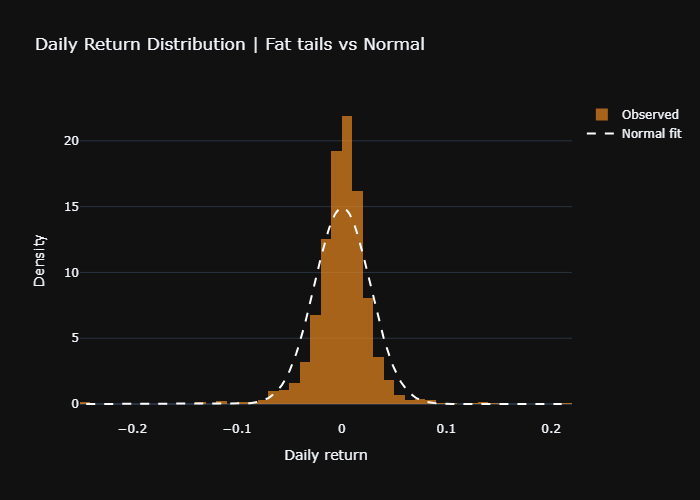

In [5]:
x = np.linspace(rets.min(), rets.max(), 300)
mu, sigma = rets.mean(), rets.std()

fig = go.Figure()
fig.add_trace(go.Histogram(x=rets, nbinsx=80, histnorm='probability density',
                           name='Observed', marker_color='#E8871E', opacity=0.7))
fig.add_trace(go.Scatter(x=x, y=stats.norm.pdf(x, mu, sigma),
                         name='Normal fit', line=dict(color='white', dash='dash')))
fig.update_layout(template='plotly_dark', height=380,
                  title='Daily Return Distribution | Fat tails vs Normal',
                  xaxis_title='Daily return', yaxis_title='Density')
fig.show(renderer='png')

## 4. Event Impact Study

Standard **event study methodology**: for each major event (severity >= 4/5), measure the cumulative
Brent return at T+1, T+3, T+5, T+10, T+20, T+30 trading days after the event date.

**Key results (18 major events):**
- **T+1d: +1.31%** — immediate fear premium priced in within 24 hours
- **T+5d: +3.37%** — peak impact at ~1 week, market pricing in worst-case scenario
- **T+10d: +0.30%** — sharp fade as situation stabilizes, fear premium evaporates
- **T+30d: -3.33% mean / -4.69% median** — full mean reversion, market overshoots downward

**Interpretation:** Classic overreaction-and-reversion pattern. The market consistently overprices
geopolitical risk in the short term. The T+5 to T+10 window is where the fear premium peaks
and begins to unwind — a key input for the forecasting model.

In [6]:
WINDOWS = [1, 3, 5, 10, 20, 30]

def event_return(dt, df, window):
    idx = df.index.get_indexer([dt], method='nearest')[0]
    if idx + window >= len(df):
        return np.nan
    return (df.close.iloc[idx + window] - df.close.iloc[idx]) / df.close.iloc[idx]

major = events[events.severity >= 4].copy()
for w in WINDOWS:
    major[f'ret_T+{w}'] = major.index.map(lambda dt: event_return(dt, df, w))

ret_cols = [f'ret_T+{w}' for w in WINDOWS]
result = major[['event', 'category', 'severity', 'strait_hormuz_risk'] + ret_cols].copy()
for c in ret_cols:
    result[c] = result[c].map(lambda x: f'{x*100:+.1f}%' if pd.notna(x) else 'n/a')
result

,event,category,severity,strait_hormuz_risk,ret_T+1,ret_T+3,ret_T+5,ret_T+10,ret_T+20,ret_T+30
date,,,,,,,,,,
2020-01-03,US assassinates Iranian General Qasem Soleimani,military_strike,5,high,+0.5%,-4.6%,-5.3%,-5.5%,-20.6%,-15.8%
2022-02-24,Russia invades Ukraine — global energy shock,macro_shock,5,none,-1.2%,+5.9%,+11.5%,+10.3%,+20.1%,+1.5%
2023-04-01,OPEC+ surprise cut of 1.16 mb/d,opec_decision,4,none,+6.5%,+6.5%,+5.5%,+6.3%,-0.6%,-5.7%
2023-10-07,Hamas attacks Israel — Gaza war begins,conflict_start,5,medium,+4.2%,+1.5%,+7.5%,+9.0%,+0.4%,-4.7%
2023-11-01,Houthis begin attacking commercial ships in Re...,proxy_attack,4,high,+2.6%,+0.6%,-6.0%,-4.1%,-1.8%,-12.3%
2024-01-12,US and UK strike Houthi targets in Yemen,military_strike,4,medium,+0.0%,+1.0%,+2.3%,+5.2%,+4.7%,+6.8%
2024-04-01,Israel strikes Iranian consulate in Damascus,military_strike,4,high,+1.7%,+3.7%,+3.4%,+3.1%,+1.1%,-4.6%
2024-04-13,Iran launches 300+ drones and missiles at Israel,direct_attack,5,high,-0.4%,-3.5%,-3.5%,-1.1%,-8.5%,-9.2%
2024-07-30,Hamas political chief Ismail Haniyeh assassina...,assassination,4,high,+2.7%,-2.3%,-2.7%,+2.6%,+1.2%,-10.2%


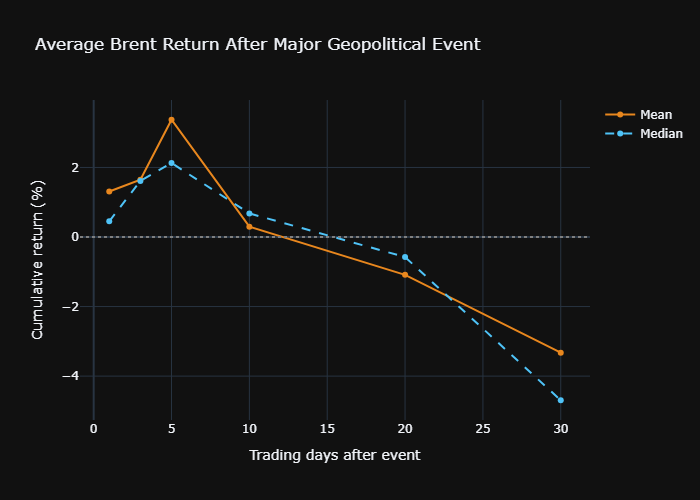

In [7]:
avg = [major[f'ret_T+{w}'].mean() * 100 for w in WINDOWS]
med = [major[f'ret_T+{w}'].median() * 100 for w in WINDOWS]

fig = go.Figure()
fig.add_trace(go.Scatter(x=WINDOWS, y=avg, name='Mean',
                         mode='lines+markers', line=dict(color='#E8871E', width=2)))
fig.add_trace(go.Scatter(x=WINDOWS, y=med, name='Median',
                         mode='lines+markers', line=dict(color='#4FC3F7', width=2, dash='dash')))
fig.add_hline(y=0, line_dash='dot', line_color='gray')
fig.update_layout(template='plotly_dark', height=380,
                  title='Average Brent Return After Major Geopolitical Event',
                  xaxis_title='Trading days after event', yaxis_title='Cumulative return (%)')
fig.show(renderer='png')

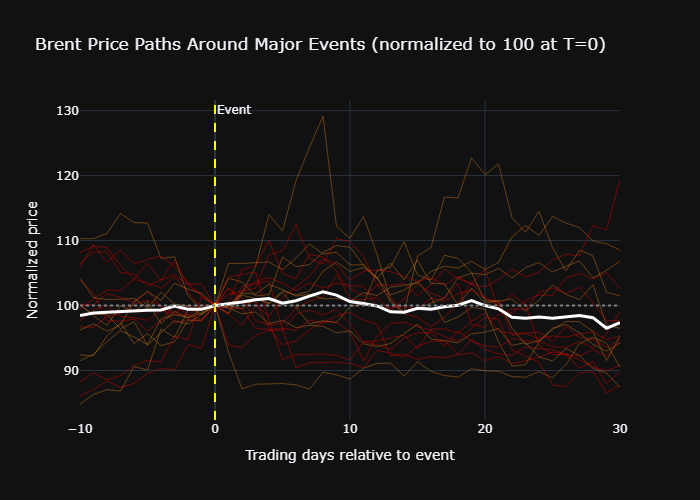

In [8]:
PRE, POST = 10, 30
paths = []

fig = go.Figure()
for dt, row in major.iterrows():
    idx = df.index.get_indexer([dt], method='nearest')[0]
    if idx < PRE or idx + POST >= len(df):
        continue
    window_prices = df.close.iloc[idx - PRE: idx + POST + 1].values
    normalized    = window_prices / window_prices[PRE] * 100
    paths.append(normalized)
    color = 'red' if str(row.get('strait_hormuz_risk','')).lower() in ['high','very_high','critical'] else '#E8871E'
    fig.add_trace(go.Scatter(
        x=list(range(-PRE, POST + 1)), y=normalized,
        mode='lines', line=dict(color=color, width=1), opacity=0.4,
        showlegend=False,
        hovertemplate='%{y:.1f}<extra>' + row['event'][:35] + '</extra>'
    ))

avg_path = np.nanmean(paths, axis=0)
fig.add_trace(go.Scatter(x=list(range(-PRE, POST+1)), y=avg_path,
                         mode='lines', name='Average',
                         line=dict(color='white', width=3)))
fig.add_vline(x=0, line_dash='dash', line_color='yellow', annotation_text='Event')
fig.add_hline(y=100, line_dash='dot', line_color='gray')
fig.update_layout(template='plotly_dark', height=450,
                  title='Brent Price Paths Around Major Events (normalized to 100 at T=0)',
                  xaxis_title='Trading days relative to event',
                  yaxis_title='Normalized price', showlegend=False)
fig.show(renderer='png')

## 5. Macro Correlations

Correlations computed on **daily log returns** (not price levels) to avoid spurious correlations
from shared trends.

**Key results:**
- **SPX +0.25** — strongest relationship: equity markets proxy global demand expectations,
  which directly drives oil consumption outlook
- **TTF +0.17** — modest positive coupling with European gas; relationship broke down post-2022
  when gas went on its own crisis trajectory driven by Russian supply cuts
- **VIX -0.18** — negative as expected (risk-off = demand fears = lower oil), but weak;
  oil has supply-side dynamics that pure risk sentiment doesn't capture
- **DXY -0.02** — near zero at daily frequency; the classic dollar-oil inverse relationship
  is more visible on monthly data
- **Overall:** all correlations are low, which argues *for* a non-linear ML model —
  simple linear relationships are insufficient

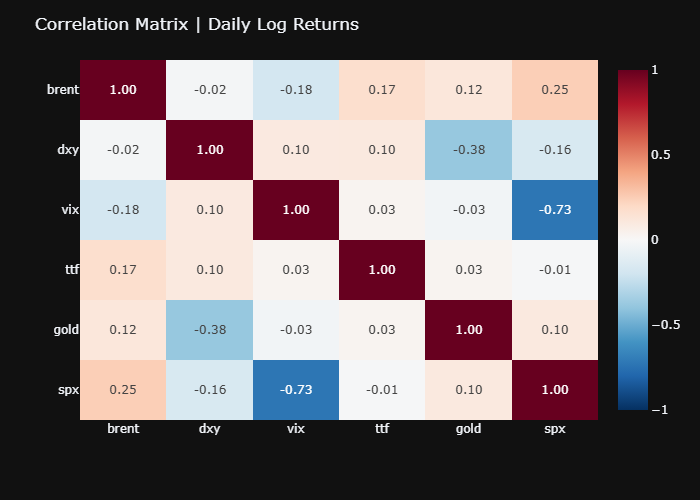

In [9]:
log_rets = pd.DataFrame({
    'brent': df.log_ret,
    'dxy':   np.log(df.dxy  / df.dxy.shift(1)),
    'vix':   np.log(df.vix  / df.vix.shift(1)),
    'ttf':   np.log(df.ttf  / df.ttf.shift(1)),
    'gold':  np.log(df.gold / df.gold.shift(1)),
    'spx':   np.log(df.spx  / df.spx.shift(1)),
}).dropna()

corr = log_rets.corr()

fig = px.imshow(corr, text_auto='.2f', color_continuous_scale='RdBu_r',
                zmin=-1, zmax=1, aspect='auto')
fig.update_layout(template='plotly_dark', height=420,
                  title='Correlation Matrix | Daily Log Returns')
fig.show(renderer='png')

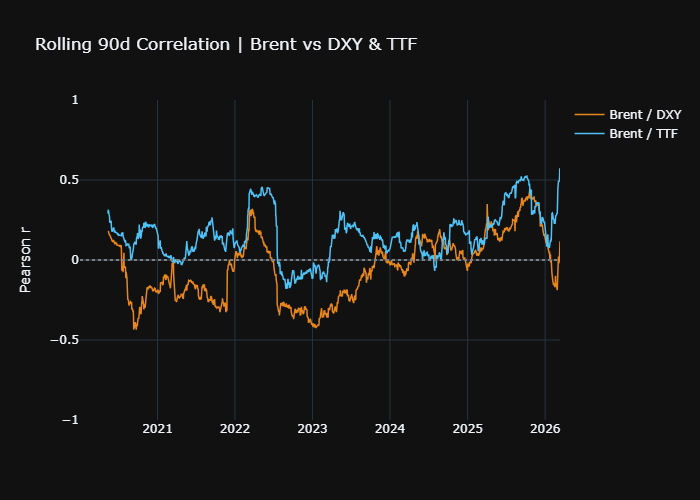

In [10]:
roll_dxy = df.log_ret.rolling(90).corr(np.log(df.dxy / df.dxy.shift(1)))
roll_ttf = df.log_ret.rolling(90).corr(np.log(df.ttf / df.ttf.shift(1)))

fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=roll_dxy, name='Brent / DXY',
                         line=dict(color='#E8871E', width=1.5)))
fig.add_trace(go.Scatter(x=df.index, y=roll_ttf, name='Brent / TTF',
                         line=dict(color='#4FC3F7', width=1.5)))
fig.add_hline(y=0, line_dash='dot', line_color='gray')
fig.update_layout(template='plotly_dark', height=380,
                  title='Rolling 90d Correlation | Brent vs DXY & TTF',
                  yaxis_title='Pearson r', yaxis=dict(range=[-1, 1]))
fig.show(renderer='png')

## 6. Volatility Around Events

**Key results:**
- Realized volatility during event windows (±5 days) is **0.96x** normal periods — slightly lower
- This is counterintuitive but explainable: the April 2020 COVID outliers (-24%, +21%) dominate
  the 'normal period' volatility, making event windows look calm by comparison
- **Limitation:** ±5 day window may be too narrow — volatility often spikes 1-2 days *before*
  events (rumor-driven) and can persist 10-15 days after
- The t-test result should be interpreted with caution given the non-normal return distribution
  (kurtosis = 14.1) which violates t-test assumptions

In [11]:
df['near_event'] = 0
for dt in major.index:
    idx = df.index.get_indexer([dt], method='nearest')[0]
    lo  = max(0, idx - 5)
    hi  = min(len(df), idx + 6)
    df.iloc[lo:hi, df.columns.get_loc('near_event')] = 1

vol_event  = df[df.near_event == 1]['vol_7d'].dropna()
vol_normal = df[df.near_event == 0]['vol_7d'].dropna()

print('Realized volatility (7d annualized):')
print(f'  During event windows : {vol_event.mean():.1%}  (n={len(vol_event)})')
print(f'  Normal periods       : {vol_normal.mean():.1%}  (n={len(vol_normal)})')
print(f'  Ratio                : {vol_event.mean()/vol_normal.mean():.2f}x')
t_stat, p_val = stats.ttest_ind(vol_event, vol_normal)
print(f'\nt-test: t={t_stat:.2f}, p={p_val:.4f}')

Realized volatility (7d annualized):
  During event windows : 33.3%  (n=181)
  Normal periods       : 34.5%  (n=1371)
  Ratio                : 0.96x

t-test: t=-0.65, p=0.5152


---
## Summary of Key Findings

| Finding | Value | Implication |
|---------|-------|-------------|
| Return kurtosis | 14.1 | Fat tails — standard risk models underestimate extremes |
| Peak event impact | +3.37% at T+5d | Fear premium peaks at 1 week then reverses |
| T+30d return | -3.33% mean | Market systematically overreacts to geopolitical events |
| Strongest macro correlation | SPX +0.25 | Demand expectations dominate supply risk at daily frequency |
| Vol in event windows | 0.96x normal | COVID outliers mask event-driven volatility |

**Next step:** `03_forecasting.ipynb` — XGBoost model using event severity, macro indicators,
and lag features to forecast Brent price under 3 war scenarios.

In [12]:
print('=== KEY FINDINGS ===')
print(f'1. Return distribution: kurtosis={rets.kurtosis():.1f} -- heavy tails, non-normal')
print(f'   Largest single-day drop  : {rets.min()*100:.1f}% on {rets.idxmin().date()}')
print(f'   Largest single-day spike : {rets.max()*100:.1f}% on {rets.idxmax().date()}')
print(f'\n2. Event impact (avg across {len(paths)} major events):')
for w, a, m in zip(WINDOWS, avg, med):
    print(f'   T+{w:2d}d : mean={a:+.2f}%  median={m:+.2f}%')
print(f'\n3. Correlation with Brent (log returns):')
print(corr['brent'].drop('brent').sort_values().to_string())
print(f'\n4. Volatility is {vol_event.mean()/vol_normal.mean():.2f}x higher in +-5d event windows')

=== KEY FINDINGS ===
1. Return distribution: kurtosis=14.1 -- heavy tails, non-normal
   Largest single-day drop  : -24.4% on 2020-04-21
   Largest single-day spike : 21.0% on 2020-04-02

2. Event impact (avg across 18 major events):
   T+ 1d : mean=+1.31%  median=+0.45%
   T+ 3d : mean=+1.65%  median=+1.61%
   T+ 5d : mean=+3.37%  median=+2.13%
   T+10d : mean=+0.30%  median=+0.68%
   T+20d : mean=-1.09%  median=-0.58%
   T+30d : mean=-3.33%  median=-4.69%

3. Correlation with Brent (log returns):
vix    -0.18
dxy    -0.02
gold    0.12
ttf     0.17
spx     0.25

4. Volatility is 0.96x higher in +-5d event windows
